patients in file: 235
                Modality  Available  Missing  Available_Percentage  \
0       Overall survival        234        1             99.574468   
2         RNA sequencing        175       60             74.468085   
3            Genomic/WES        136       99             57.872340   
1  Clinical/pathological         97      138             41.276596   
4            Methylation         56      179             23.829787   

   Missing_Percentage  
0            0.425532  
2           25.531915  
3           42.127660  
1           58.723404  
4           76.170213  


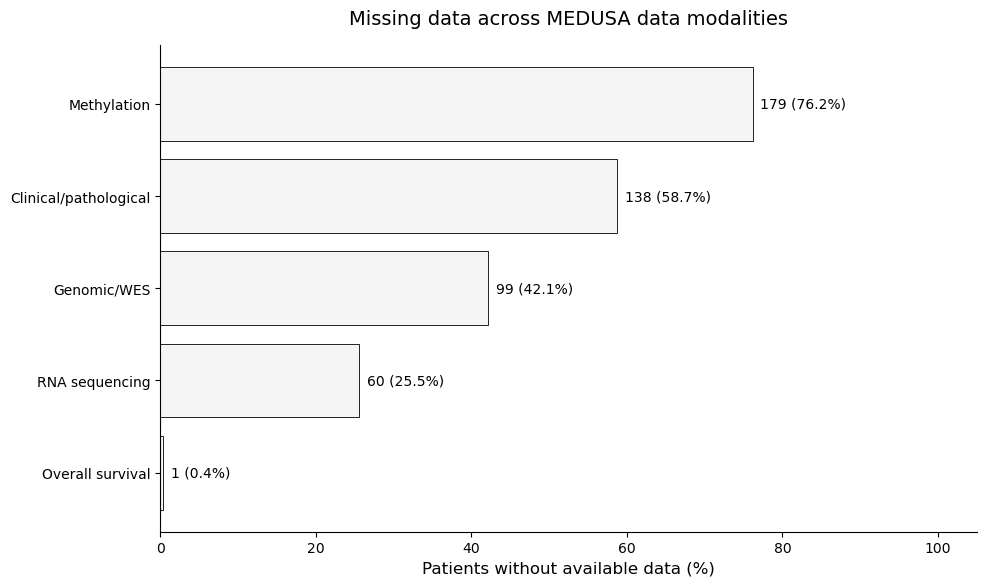

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths for the MEDUSA file and where I want the finished figure saved
raw_path = "/home/rt334/Downloads/MEDUSA_Master_ULTIMATE.csv"
output_dir = Path("/home/rt334/Independent/Hermes/MEDUSA_figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Keep the text sizes consistent across the figure
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Read in the master dataset
df = pd.read_csv(raw_path, low_memory=False)
id_col = "MEDUSA_Subject_ID"

# The description row contains the useful column names, so use these where available
desc_row = df[df[id_col] == "MEDDESCRIPTION"]
if len(desc_row) > 0:
    desc_row = desc_row.iloc[0]
    rename_map = {c: desc_row[c] for c in df.columns
                  if c != id_col and pd.notna(desc_row[c]) and desc_row[c] != c}
    df = df.rename(columns=rename_map)

# Remove the two metadata rows so I'm only counting actual patients
df = df[~df[id_col].astype(str).isin(["MEDDESCRIPTION", "MEDFEATURE"])].copy()

total_patients = len(df)
print(f"patients in file: {total_patients}")

# Double check that any NA values have actually been recognised as missing
for col in ["Age", "Overall survival (Surgery-to-Death) in days"]:
    if col in df.columns:
        weird = df[col].astype(str).str.strip().str.upper()
        n_literal_na = (weird == "NA").sum()
        if n_literal_na > 0:
            print(f"WARNING: found {n_literal_na} literal 'NA' strings in {col}, these need fixing")

# Pick one representative column for each type of data
modality_cols = {
    "Overall survival": "Overall survival (Surgery-to-Death) in days",
    "Clinical/pathological": "Age",
    "RNA sequencing": "ssGSEA:HALLMARK_ADIPOGENESIS",
    "Genomic/WES": "Mutation BAP1",
    "Methylation": "ageAcc.Horvath",
}

# Count how many patients have data available for each modality
rows = []
for label, col in modality_cols.items():
    if col not in df.columns:
        print(f"couldn't find column '{col}' for {label} - skipping")
        continue
    available = df[col].notna().sum()
    rows.append({"Modality": label, "Available": available})

# Work out the missing counts and percentages
modality_data = pd.DataFrame(rows)
modality_data["Missing"] = total_patients - modality_data["Available"]
modality_data["Available_Percentage"] = modality_data["Available"] / total_patients * 100
modality_data["Missing_Percentage"] = modality_data["Missing"] / total_patients * 100

# Order the modalities from least to most missing
modality_data = modality_data.sort_values("Missing_Percentage", ascending=True)

print(modality_data)

# Plot the missing data as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    modality_data["Modality"],
    modality_data["Missing_Percentage"],
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.6
)

# Add the patient count and percentage beside each bar
for bar, missing_count, missing_percentage in zip(
    bars, modality_data["Missing"], modality_data["Missing_Percentage"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{missing_count} ({missing_percentage:.1f}%)",
        va="center",
        fontsize=10
    )

# Final formatting
ax.set_title("Missing data across MEDUSA data modalities", pad=15)
ax.set_xlabel("Patients without available data (%)")
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Save a high-resolution copy for the dissertation
plt.tight_layout()
plt.savefig(output_dir / "Figure_1_missing_data_by_modality.png", dpi=600, bbox_inches="tight")
plt.show()

patients with histology data: 97
  Histological subtype  Count  Percentage
0          Epithelioid     88   90.721649
1             Biphasic      8    8.247423
2          Sarcomatoid      1    1.030928


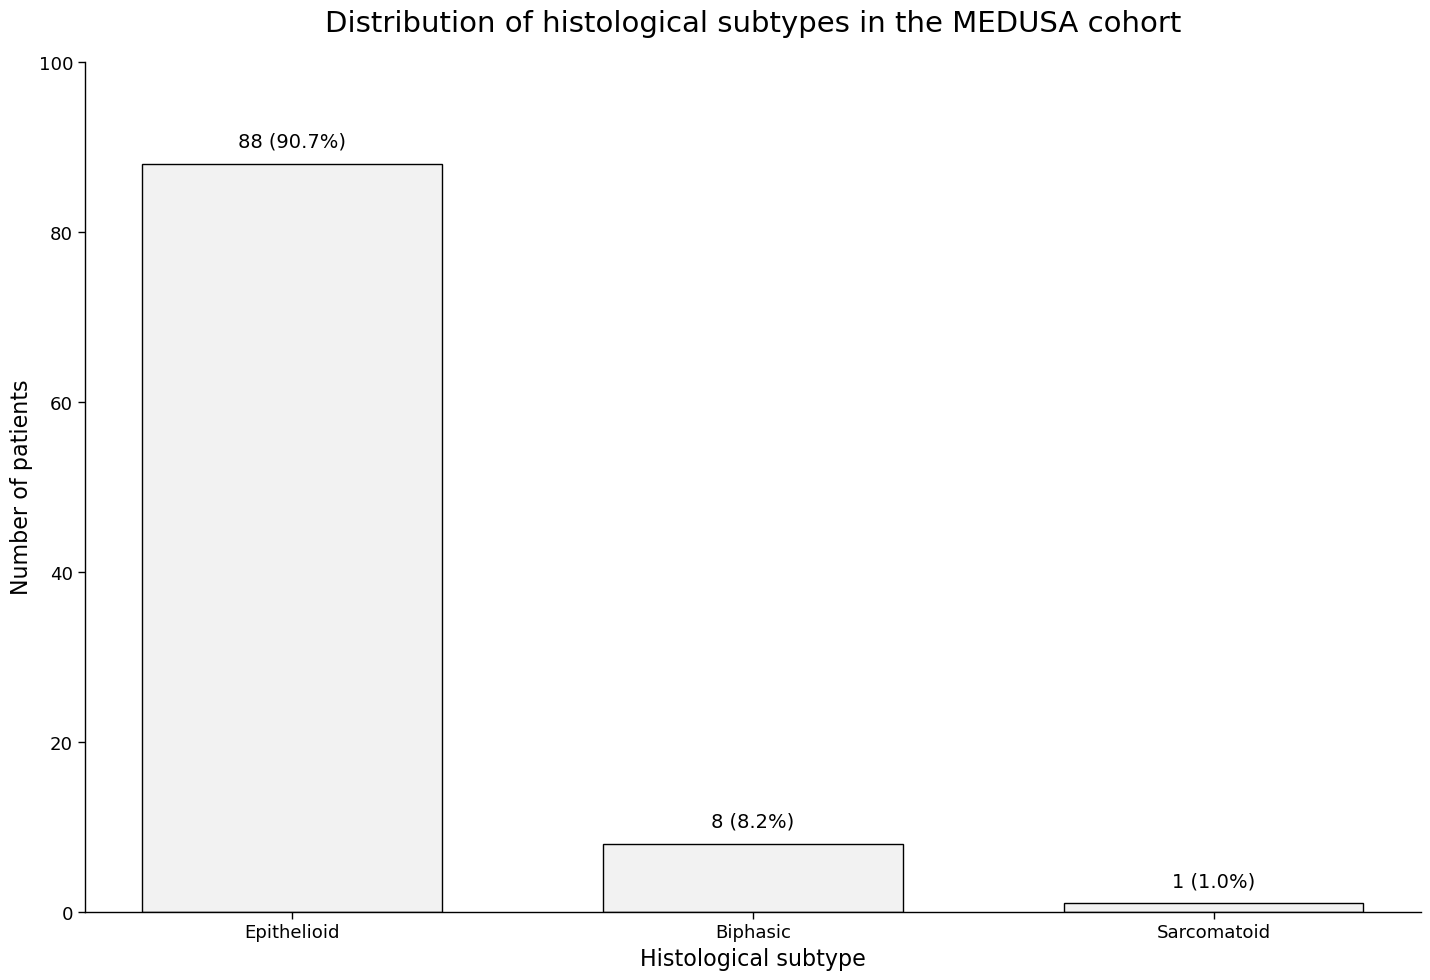

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Where I want the finished figure saved
output_dir = Path("/home/rt334/Independent/Hermes/MEDUSA_figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Keep the formatting consistent with the original figure
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.titlesize": 21,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

# Histological subtype counts from the MEDUSA cohort
histology_data = pd.DataFrame({
    "Histological subtype": [
        "Epithelioid",
        "Biphasic",
        "Sarcomatoid"
    ],
    "Count": [
        88,
        8,
        1
    ]
})

# Calculate percentages from the 97 patients with histology data
total_histology = histology_data["Count"].sum()

histology_data["Percentage"] = (
    histology_data["Count"] / total_histology * 100
)

print(f"patients with histology data: {total_histology}")
print(histology_data)

# Build the bar chart
fig, ax = plt.subplots(
    figsize=(14.5, 10),
    facecolor="white"
)

x_positions = [0, 1, 2]

bars = ax.bar(
    x_positions,
    histology_data["Count"],
    width=0.65,
    color="#f2f2f2",
    edgecolor="black",
    linewidth=1.0
)

# Add count and percentage above each bar
for bar, count, percentage in zip(
    bars,
    histology_data["Count"],
    histology_data["Percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{count} ({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=14
    )

# Add the subtype labels
ax.set_xticks(x_positions)
ax.set_xticklabels(
    histology_data["Histological subtype"]
)

# Match the original 0–100 y-axis
ax.set_ylim(0, 100)

ax.set_yticks([
    0,
    20,
    40,
    60,
    80,
    100
])

# Match the spacing around the bars
ax.set_xlim(-0.45, 2.45)

# Axis titles and figure title
ax.set_title(
    "Distribution of histological subtypes in the MEDUSA cohort",
    pad=22
)

ax.set_xlabel(
    "Histological subtype"
)

ax.set_ylabel(
    "Number of patients"
)

# Match the clean appearance of the original
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)

ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1.0
)

ax.grid(False)

# Keep the background completely white
ax.set_facecolor("white")

# Save a high-resolution copy for the dissertation
plt.tight_layout()

plt.savefig(
    output_dir / "Figure_2_histology_distribution.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()